### Imports et configurations

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/predictive_maintenance_v3.csv"
FIGURES_PATH = "../reports/figures"

os.makedirs(FIGURES_PATH, exist_ok=True)

### Chargement du dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

df.head()

Shape : (24042, 15)

Colonnes :
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost']


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


### Vérification rapide de la structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  object 
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  object 
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  object 
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  object 
 14  estimated_repair_cost 

In [6]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


### Conversion des types utiles

In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

categorical_cols = ["machine_type", "operating_mode", "failure_type"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[ns]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  category      
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  category      
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 n

### Gestion des valeurs manquantes

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
})

missing_df

,missing_count,missing_pct
vibration_rms,1000,4.16
pressure_level,924,3.84
temperature_motor,834,3.47
current_phase_avg,731,3.04
rpm,533,2.22
timestamp,0,0.00
machine_id,0,0.00
machine_type,0,0.00
operating_mode,0,0.00
hours_since_maintenance,0,0.00


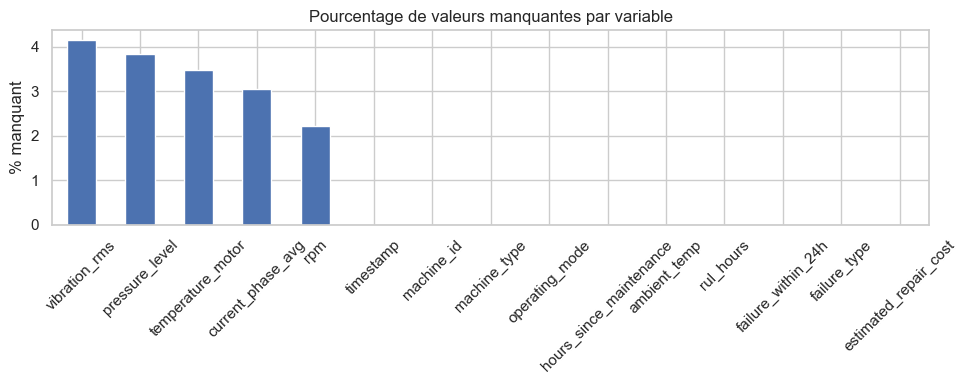

In [9]:
plt.figure(figsize=(10, 4))
missing_df["missing_pct"].plot(kind="bar")
plt.title("Pourcentage de valeurs manquantes par variable")
plt.ylabel("% manquant")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/missing_values.png")
plt.show()

### Nombre de doublons

In [13]:
print("Nombre de doublons exacts :", df.duplicated().sum())

Nombre de doublons exacts : 0


### Séparation des données numériques et catégorielles

In [14]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

print("Colonnes numériques :", numeric_cols)
print("\nColonnes catégorielles :", categorical_cols)

Colonnes numériques : ['machine_id', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'estimated_repair_cost']

Colonnes catégorielles : ['machine_type', 'operating_mode', 'failure_type']


### Distribution des variables numériques

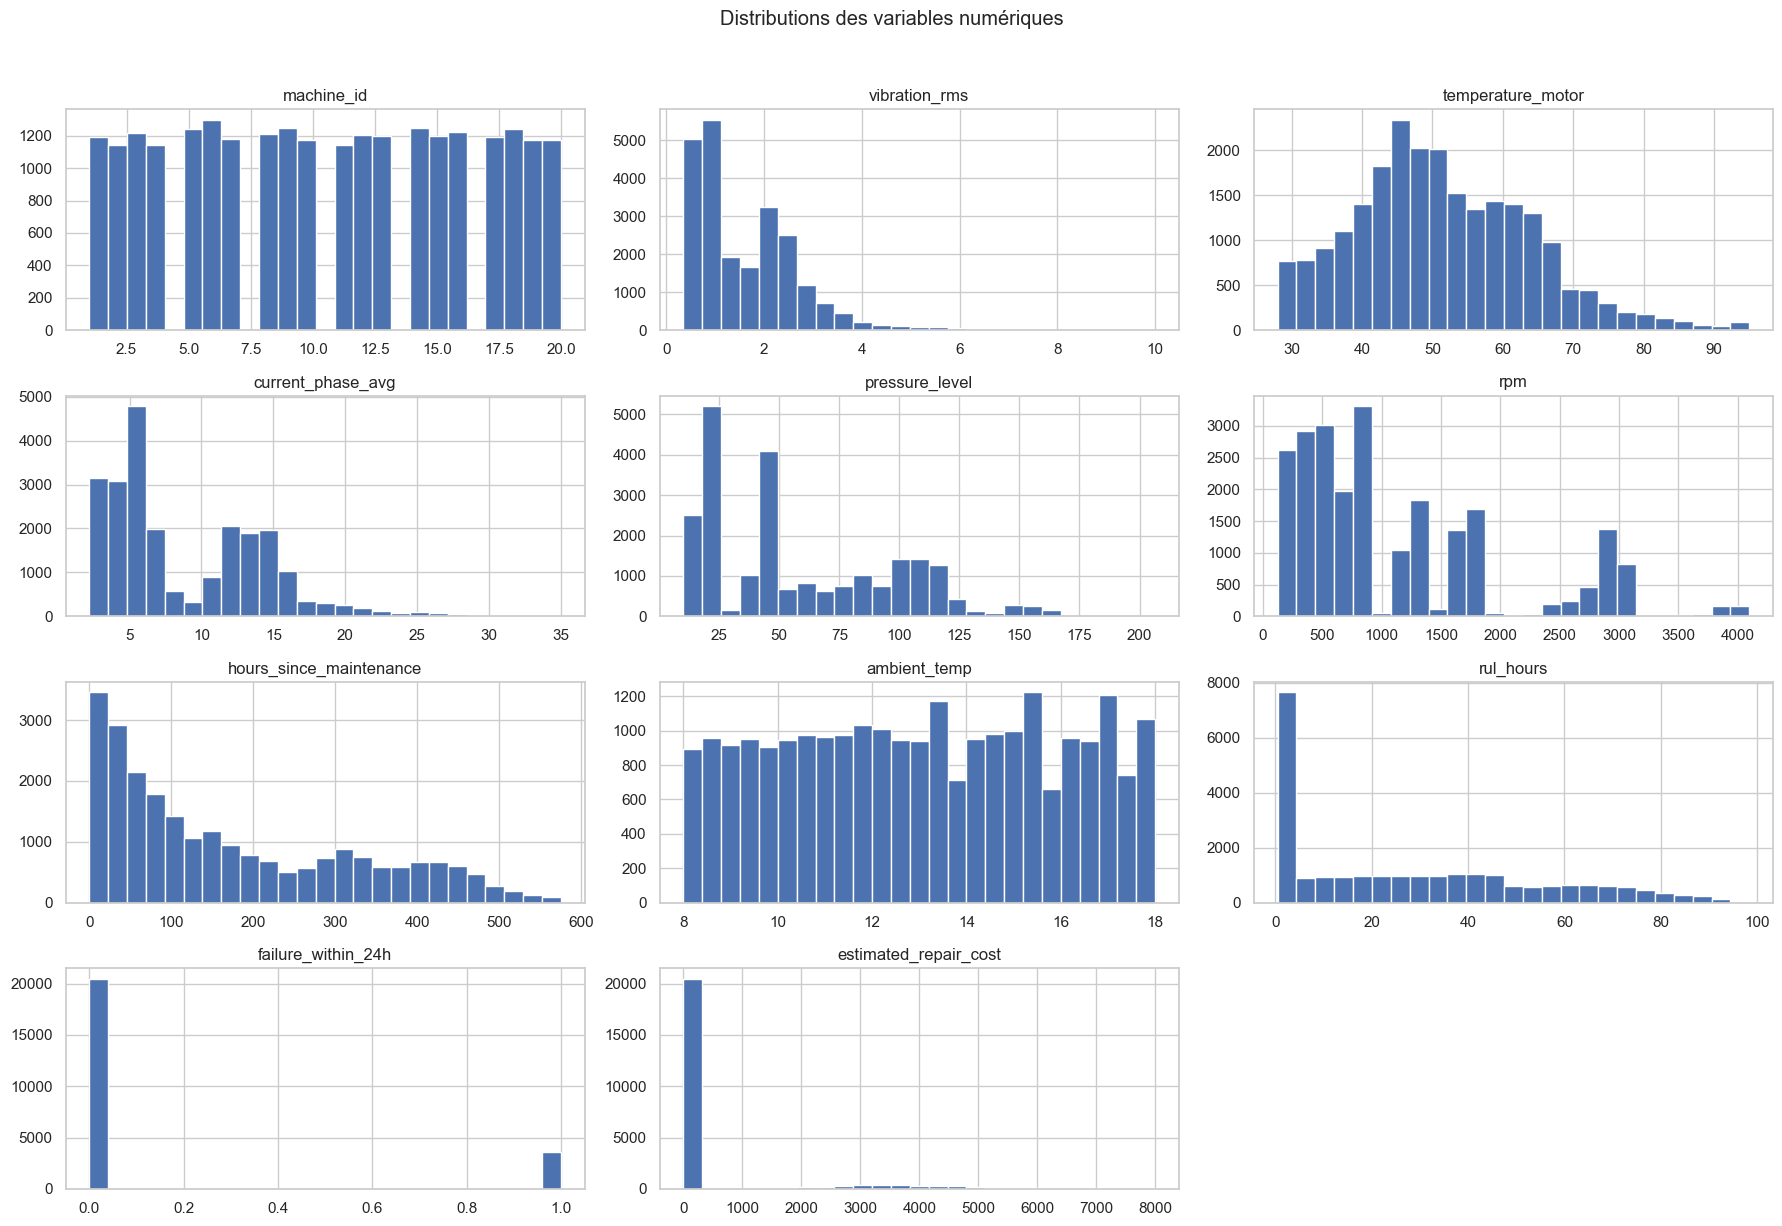

In [15]:
df[numeric_cols].hist(bins=25, figsize=(18, 12))
plt.suptitle("Distributions des variables numériques", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/numeric_distributions.png")
plt.show()

### Boxplots pour répérer les outliers

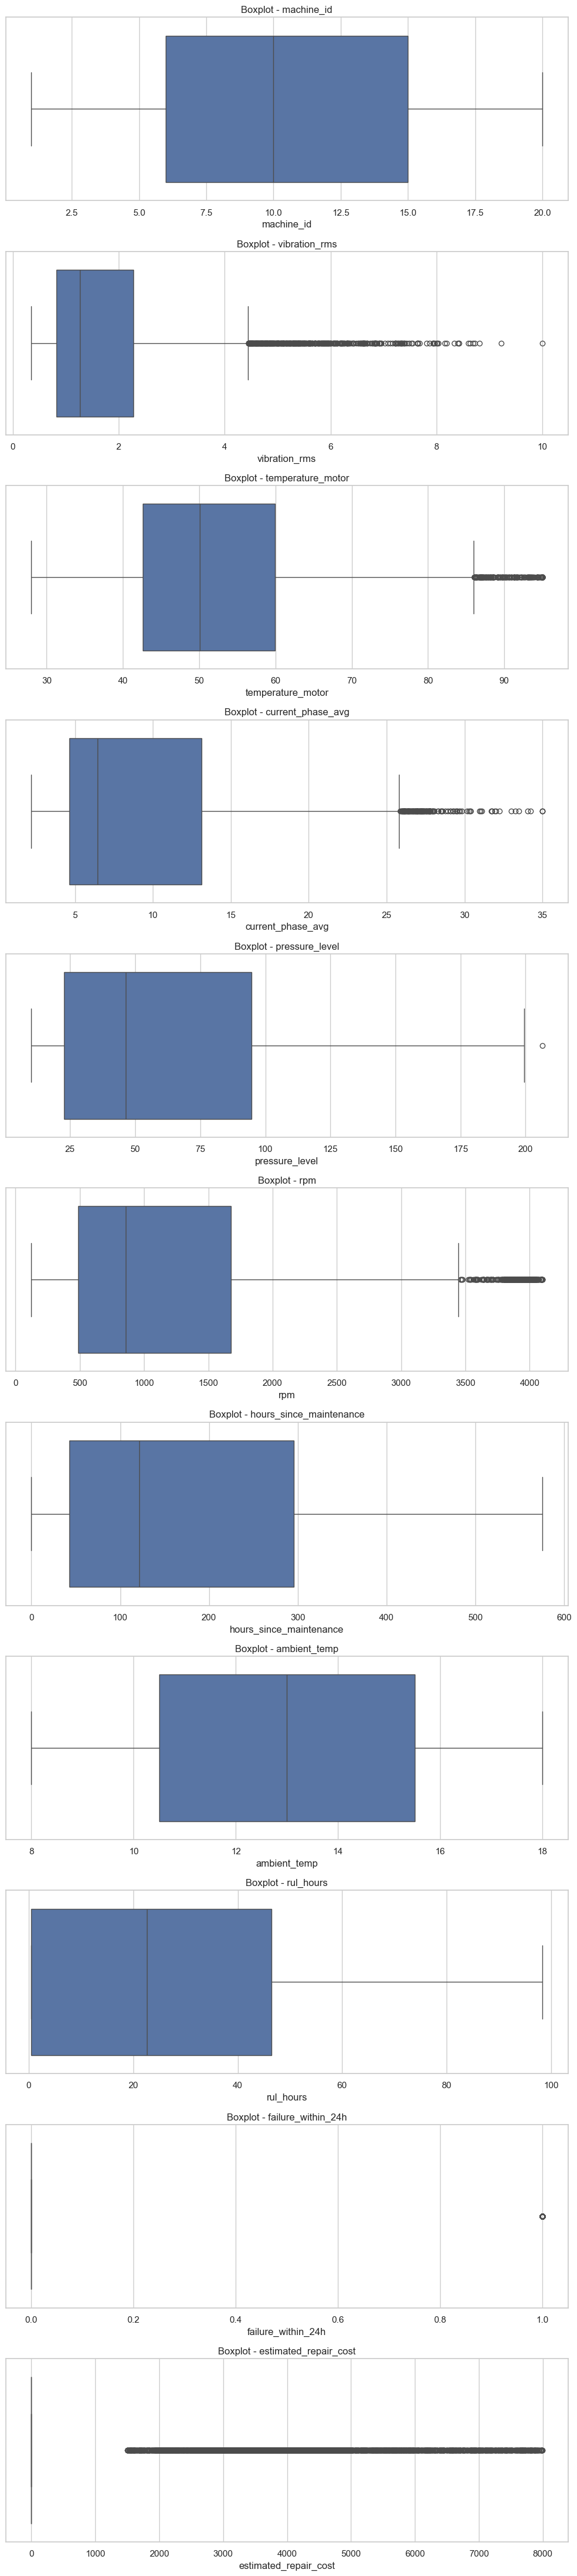

In [16]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot - {col}")

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/boxplots_numeric.png")
plt.show()

### Matrice de corrélation

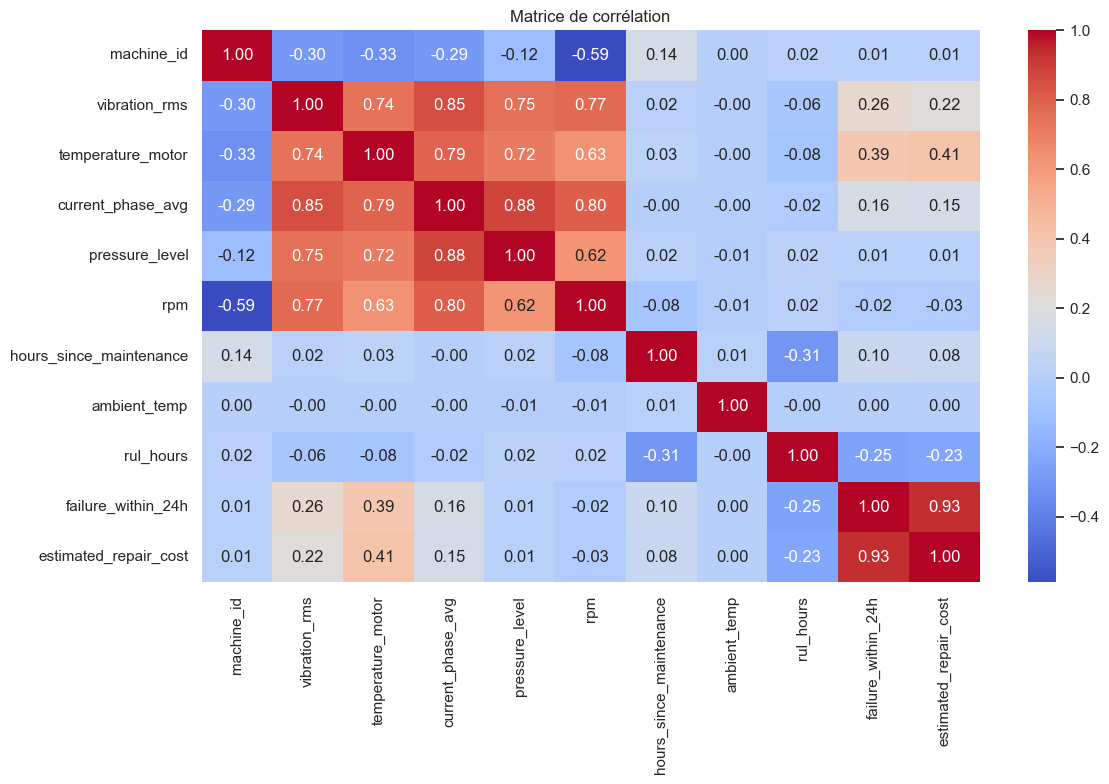

In [17]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/correlation_matrix.png")
plt.show()

### Analyse des variables catégorielles

In [18]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== machine_type ===
machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64

=== operating_mode ===
operating_mode
normal    11632
idle      10862
peak       1548
Name: count, dtype: int64

=== failure_type ===
failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64


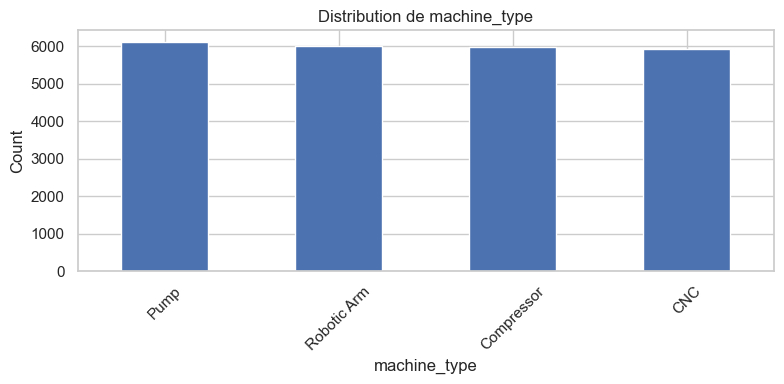

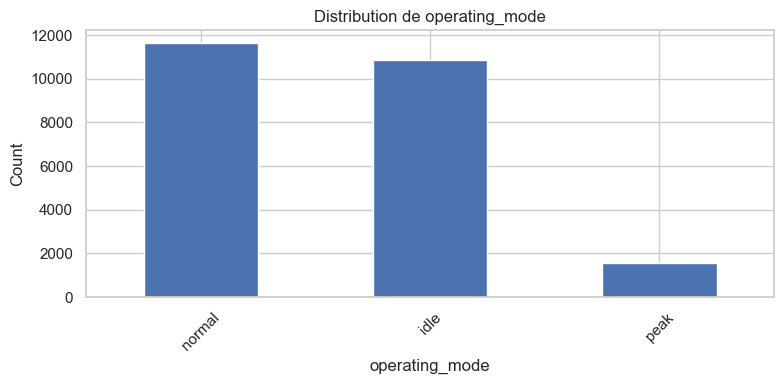

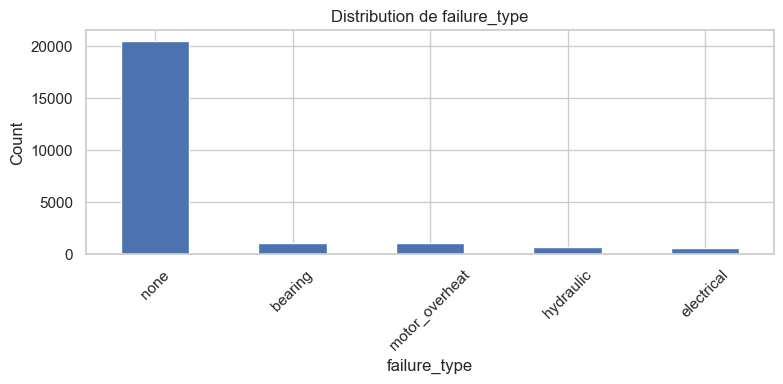

In [19]:
for col in ["machine_type", "operating_mode", "failure_type"]:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution de {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_PATH}/{col}_distribution.png")
    plt.show()

## Conclusions EDA

- Les variables capteurs (vibration, température, pression, rpm) sont fortement corrélées entre elles, ce qui est cohérent avec un système industriel.
- La variable `failure_within_24h` est déséquilibrée (majorité de 0), ce qui nécessite l’utilisation de métriques adaptées comme le F1-score.
- La variable `estimated_repair_cost` est fortement corrélée avec `failure_within_24h` (0.93), ce qui indique un risque de data leakage. Elle sera donc exclue des modèles prédictifs.
- La variable `rul_hours` présente peu de corrélations linéaires avec les autres variables, suggérant des relations non linéaires. Elle sera conservée comme tâche bonus.
- Les colonnes `machine_id` et `timestamp` ne seront pas utilisées comme features car elles n’apportent pas d’information prédictive directe.